# Taylor-LSTM: Model Visualization

Architecture diagram and training progress for our character-level LSTM lyrics generator.

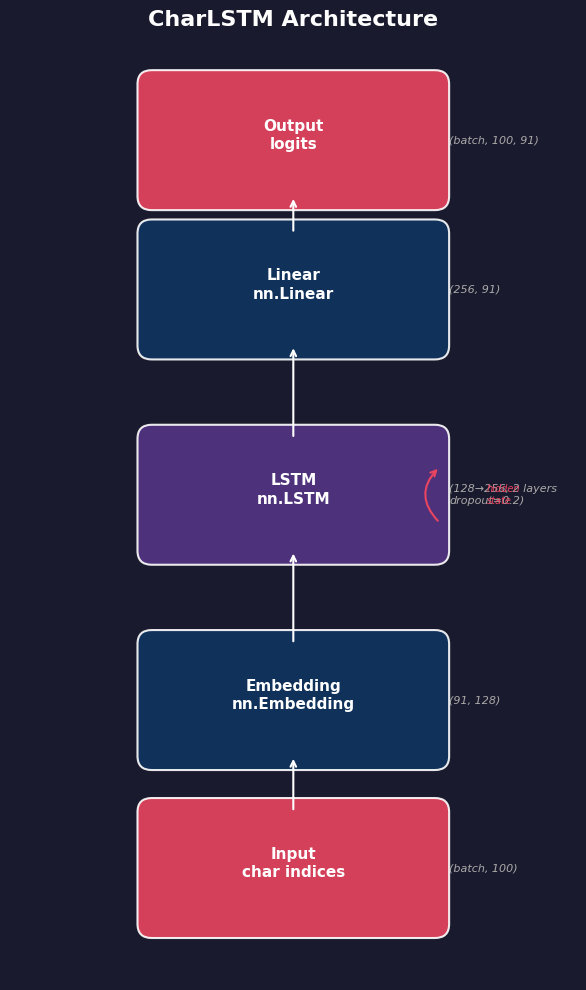

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 10))
ax.set_xlim(0, 6)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Layer definitions: (label, y_center, color, shape_text)
layers = [
    ('Input\nchar indices',        1.2, '#e94560', '(batch, 100)'),
    ('Embedding\nnn.Embedding',     3.0, '#0f3460', '(91, 128)'),
    ('LSTM\nnn.LSTM',              5.2, '#533483', '(128→256, 2 layers\ndropout=0.2)'),
    ('Linear\nnn.Linear',          7.4, '#0f3460', '(256, 91)'),
    ('Output\nlogits',             9.0, '#e94560', '(batch, 100, 91)'),
]

box_w, box_h = 3.0, 1.2
cx = 3.0  # center x

for label, y, color, shape in layers:
    fancy = mpatches.FancyBboxPatch(
        (cx - box_w/2, y - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.15', facecolor=color, edgecolor='white',
        linewidth=1.5, alpha=0.9
    )
    ax.add_patch(fancy)
    ax.text(cx, y + 0.05, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', linespacing=1.3)
    ax.text(cx + box_w/2 + 0.15, y, shape, ha='left', va='center',
            fontsize=8, color='#aaaaaa', fontstyle='italic')

# Arrows between layers
arrow_props = dict(arrowstyle='->', color='white', lw=1.5)
arrow_ys = [(1.8, 2.4), (3.6, 4.6), (5.8, 6.8), (8.0, 8.4)]
for y_start, y_end in arrow_ys:
    ax.annotate('', xy=(cx, y_end), xytext=(cx, y_start), arrowprops=arrow_props)

# Hidden state recurrence arrow on LSTM
ax.annotate('', xy=(cx + box_w/2 + 0.05, 5.5),
            xytext=(cx + box_w/2 + 0.05, 4.9),
            arrowprops=dict(arrowstyle='->', color='#e94560', lw=1.5,
                            connectionstyle='arc3,rad=-0.5'))
ax.text(cx + box_w/2 + 0.55, 5.2, 'hidden\nstate', ha='left', va='center',
        fontsize=7, color='#e94560', fontstyle='italic')

ax.set_title('CharLSTM Architecture', fontsize=16, fontweight='bold',
             color='white', pad=15)
plt.tight_layout()
plt.show()

In [2]:
# Optional: torchinfo text summary
try:
    from torchinfo import summary
    from model import CharLSTM
    model = CharLSTM(vocab_size=91, embed_size=128, hidden_size=256, num_layers=2)
    summary(model, input_size=(1, 100), dtypes=['torch.long'])
except ImportError:
    print('torchinfo not installed — run `pip install torchinfo` for a text summary.')
    # Fallback: manual parameter count
    from model import CharLSTM
    model = CharLSTM(vocab_size=91, embed_size=128, hidden_size=256, num_layers=2)
    total = sum(p.numel() for p in model.parameters())
    print(f'CharLSTM — {total:,} parameters')
    for name, p in model.named_parameters():
        print(f'  {name:30s} {str(list(p.shape)):20s} {p.numel():>10,}')

torchinfo not installed — run `pip install torchinfo` for a text summary.


CharLSTM — 956,635 parameters
  embedding.weight               [91, 128]                11,648
  lstm.weight_ih_l0              [1024, 128]             131,072
  lstm.weight_hh_l0              [1024, 256]             262,144
  lstm.bias_ih_l0                [1024]                    1,024
  lstm.bias_hh_l0                [1024]                    1,024
  lstm.weight_ih_l1              [1024, 256]             262,144
  lstm.weight_hh_l1              [1024, 256]             262,144
  lstm.bias_ih_l1                [1024]                    1,024
  lstm.bias_hh_l1                [1024]                    1,024
  fc.weight                      [91, 256]                23,296
  fc.bias                        [91]                         91


In [3]:
import os
import torch

checkpoint_dir = 'checkpoints'
epoch_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.startswith('model_epoch')],
    key=lambda f: int(f.replace('model_epoch', '').replace('.pt', ''))
)

epochs, losses, lrs = [], [], []
for f in epoch_files:
    ckpt = torch.load(os.path.join(checkpoint_dir, f), map_location='cpu', weights_only=False)
    epochs.append(ckpt['epoch'])
    losses.append(ckpt['loss'])
    # Extract LR from optimizer state
    lr = ckpt['optimizer_state']['param_groups'][0]['lr']
    lrs.append(lr)
    print(f"{f:25s}  epoch={ckpt['epoch']:3d}  loss={ckpt['loss']:.4f}  lr={lr:.6f}")

# Also load best model
best = torch.load(os.path.join(checkpoint_dir, 'model_best.pt'), map_location='cpu', weights_only=False)
print(f"\nBest model: epoch={best['epoch']}, loss={best['loss']:.4f}")

model_epoch10.pt           epoch= 10  loss=0.7071  lr=0.000500
model_epoch20.pt           epoch= 20  loss=0.5996  lr=0.000500
model_epoch30.pt           epoch= 30  loss=0.5981  lr=0.000500
model_epoch40.pt           epoch= 40  loss=0.5366  lr=0.000250
model_epoch50.pt           epoch= 50  loss=0.5311  lr=0.000250

Best model: epoch=50, loss=0.5311


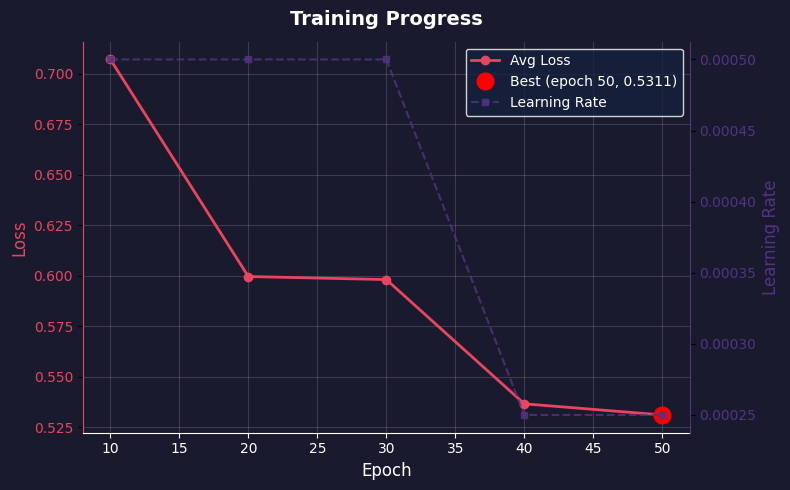

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#1a1a2e')
ax1.set_facecolor('#1a1a2e')

# Loss curve (left y-axis)
color_loss = '#e94560'
ax1.plot(epochs, losses, 'o-', color=color_loss, linewidth=2, markersize=6, label='Avg Loss')

# Mark best checkpoint
best_idx = losses.index(min(losses))
ax1.plot(epochs[best_idx], losses[best_idx], 'o', color='red', markersize=12,
         zorder=5, label=f'Best (epoch {epochs[best_idx]}, {losses[best_idx]:.4f})')

ax1.set_xlabel('Epoch', color='white', fontsize=12)
ax1.set_ylabel('Loss', color=color_loss, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.tick_params(axis='x', colors='white')
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color(color_loss)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Learning rate (right y-axis)
ax2 = ax1.twinx()
color_lr = '#533483'
ax2.plot(epochs, lrs, 's--', color=color_lr, linewidth=1.5, markersize=5, alpha=0.8, label='Learning Rate')
ax2.set_ylabel('Learning Rate', color=color_lr, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_lr)
ax2.spines['right'].set_color(color_lr)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
           facecolor='#16213e', edgecolor='white', labelcolor='white')

ax1.set_title('Training Progress', fontsize=14, fontweight='bold', color='white', pad=12)
ax1.grid(True, alpha=0.15, color='white')
plt.tight_layout()
plt.show()

## Observations

- **Steep early drop:** Most learning happens in the first 10-20 epochs.
- **LR schedule:** `ReduceLROnPlateau` (patience=3, factor=0.5) kicks in when the loss plateaus — watch for step-downs in the LR curve.
- **Best checkpoint** is marked with a red dot — this is the model used for generation.
- **Next steps:** Run `tensorboard --logdir runs` after a training run for batch-level loss granularity.